# GBP/USD Dynamic Intraday Bias Engine — V3

## Fundamental Architecture Change from V2

| Dimension | V2 | V3 |
|---|---|---|
| **Prediction cadence** | Once per day | Every 15-minute candle close |
| **Rows in dataset** | ~1,600 daily rows | ~50,000+ intraday rows (London+NY sessions) |
| **Target** | Which liquidity hit first | Binary: daily candle closes bullish (1) or bearish (0) |
| **Output** | Single class prediction | `predict_proba()` — probability updates every 15 min |
| **Trend** | MA50 + BOS on highs/lows | Close-only market structure (line chart simulation) |
| **Core signal** | Counts of FVGs | FVG respect/disrespect as conditional state changes |
| **Liquidity** | Equal highs/lows counting | Delivery-from-liquidity state machine (BSL/SSL swept) |
| **Removed** | — | All MAs, ATR, RSI, volatility regime, Random Forest |

### The "If/Then" Logic
The model learns conditional chains like:
- *"If 4H trend is bearish AND BSL was swept AND a bearish 1H FVG was just respected → P(bearish close) = 78%"*
- *"If that same FVG is then disrespected on the next 15M candle → P(bearish close) drops to 35%"*

XGBoost captures this naturally via sequential tree splits.

---
## 1. Setup

In [12]:
!pip install -q xgboost

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score, brier_score_loss
)
import xgboost as xgb

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', 60)

# ──────────────────────────────────────────────
# CONFIGURATION
# ──────────────────────────────────────────────
PAIR = 'GBPUSD'

PATHS = {
    '1D':  '/content/gbpusd_1D.csv',
    '4H':  '/content/gbpusd_4H.csv',
    '1H':  '/content/gbpusd_1H.csv',
    '15M': '/content/gbpusd_15M.csv',
}

# Session windows (UTC)
LONDON_START = 7
LONDON_END   = 12
NY_START     = 12
NY_END       = 17
ASIA_START   = 0
ASIA_END     = 7

TRAIN_RATIO  = 0.80
RANDOM_STATE = 42

print(f'Pair: {PAIR}')
print(f'Prediction window: London {LONDON_START:02d}:00 – NY close {NY_END:02d}:00 UTC')
print('V3 — Dynamic Intraday SMC Engine')

Pair: GBPUSD
Prediction window: London 07:00 – NY close 17:00 UTC
V3 — Dynamic Intraday SMC Engine


---
## 2. Data Loading

In [14]:
def load_ohlc(path: str, timeframe: str) -> pd.DataFrame:
    """Load OHLC CSV, clean placeholders, sort chronologically."""
    df = pd.read_csv(path, parse_dates=['datetime'])
    df.columns = [c.strip().lower() for c in df.columns]
    df = df.sort_values('datetime').reset_index(drop=True)
    df = df.drop_duplicates(subset='datetime')
    # Remove placeholder bars (O=H=L=C)
    mask = (df['open'] == df['high']) & (df['high'] == df['low']) & (df['low'] == df['close'])
    removed = mask.sum()
    if removed > 0:
        print(f'  Removed {removed} placeholder bars from {timeframe}')
    df = df[~mask].reset_index(drop=True)
    df = df.ffill().bfill()
    return df


data = {}
for tf, path in PATHS.items():
    data[tf] = load_ohlc(path, tf)
    print(f'{tf:>4s}: {len(data[tf]):>7,} rows  |  '
          f'{data[tf]["datetime"].min().date()} → {data[tf]["datetime"].max().date()}')

  Removed 2 placeholder bars from 1D
  1D:   1,628 rows  |  2021-01-03 → 2026-03-31
  Removed 7 placeholder bars from 4H
  4H:   8,380 rows  |  2021-01-03 → 2026-03-31
  Removed 24 placeholder bars from 1H
  1H:  32,319 rows  |  2021-01-03 → 2026-03-31
  Removed 86 placeholder bars from 15M
 15M: 129,065 rows  |  2021-01-03 → 2026-03-31


---
## 3. Feature Engineering — Pure SMC

**Removed from V2:** MA50, MA slope, price_vs_ma50, ATR, atr_percentile, rolling_vol, range_percentile, vol_regime, all interaction features that used MAs or ATR.

**What remains and what's new:** Close-only market structure, delivery-from-liquidity state, FVG respect/disrespect states, session context.

### 3A. Feature A — Close-Only HTF Market Structure

**Why close-only?** Wicks are noise. Institutions care about where price *settles*, not where it temporarily pokes. Using close prices to find swing points simulates reading a line chart — the clearest view of structure.

Swing detection uses a rolling window on **close prices only**, then checks for HH/HL (bullish) vs LH/LL (bearish) sequences.

In [15]:
def compute_close_only_structure(df: pd.DataFrame, swing_len: int = 5) -> pd.DataFrame:
    """
    V3 FEATURE A: Close-only market structure.

    Uses CLOSE prices (not highs/lows) to detect swing points,
    simulating a line chart for cleaner trend reads.

    Outputs:
    - swing_high_close: rolling max of closes (confirmed, shifted)
    - swing_low_close: rolling min of closes (confirmed, shifted)
    - close_hh: current swing high > previous swing high (Higher High)
    - close_ll: current swing low < previous swing low (Lower Low)
    - close_trend: +1 (HH+HL pattern), -1 (LH+LL pattern), 0 neutral
    """
    df = df.copy()
    closes = df['close']

    # Swing points from closes only — shifted by 1 to avoid lookahead
    df['swing_high_close'] = closes.rolling(swing_len, min_periods=swing_len).max().shift(1)
    df['swing_low_close'] = closes.rolling(swing_len, min_periods=swing_len).min().shift(1)

    # Higher High / Lower Low on close-only swings
    prev_swing_h = df['swing_high_close'].shift(swing_len)
    prev_swing_l = df['swing_low_close'].shift(swing_len)

    df['close_hh'] = (df['swing_high_close'] > prev_swing_h).astype(int)
    df['close_hl'] = (df['swing_low_close'] > prev_swing_l).astype(int)
    df['close_lh'] = (df['swing_high_close'] < prev_swing_h).astype(int)
    df['close_ll'] = (df['swing_low_close'] < prev_swing_l).astype(int)

    # Trend classification:
    # Bullish = HH AND HL,  Bearish = LH AND LL
    df['close_trend'] = np.select(
        [
            (df['close_hh'] == 1) & (df['close_hl'] == 1),
            (df['close_lh'] == 1) & (df['close_ll'] == 1),
        ],
        [1, -1],
        default=0
    )

    # BOS on close: price closes beyond previous close-swing
    df['close_bos_bull'] = (closes > df['swing_high_close']).astype(int)
    df['close_bos_bear'] = (closes < df['swing_low_close']).astype(int)

    # Track last BOS direction
    n = len(df)
    last_dir = np.zeros(n)
    dist_bos = np.zeros(n)
    cur_dir = 0
    last_idx = 0
    for i in range(n):
        if df['close_bos_bull'].iat[i] == 1:
            cur_dir = 1
            last_idx = i
        elif df['close_bos_bear'].iat[i] == 1:
            cur_dir = -1
            last_idx = i
        last_dir[i] = cur_dir
        dist_bos[i] = i - last_idx

    df['last_close_bos_dir'] = last_dir
    df['dist_from_close_bos'] = dist_bos

    # BOS counts
    df['close_bos_net_10'] = (
        df['close_bos_bull'].rolling(10, min_periods=1).sum() -
        df['close_bos_bear'].rolling(10, min_periods=1).sum()
    )

    return df


# Apply to 4H and Daily
for tf in ['4H', '1D']:
    data[tf] = compute_close_only_structure(data[tf])
    print(f'Close-only structure computed on {tf}.')

Close-only structure computed on 4H.
Close-only structure computed on 1D.


### 3B. Feature B — Delivery from Liquidity (State Machine)

This captures the ICT concept: after sweeping a liquidity pool, price *delivers* in the opposite direction. The state persists until the next sweep.

- **BSL_Swept** (+1): price took out buy-side liquidity (PDH or 4H swing high) → expecting sell delivery
- **SSL_Swept** (-1): price took out sell-side liquidity (PDL or 4H swing low) → expecting buy delivery
- **Neutral** (0): no recent sweep

In [16]:
def compute_delivery_state(df_15m: pd.DataFrame,
                            df_daily: pd.DataFrame,
                            df_4h: pd.DataFrame) -> pd.DataFrame:
    """
    V3 FEATURE B: Delivery-from-liquidity state machine.

    At each 15M bar, checks whether price has swept key liquidity:
    - Previous Day High (PDH) / Previous Day Low (PDL)
    - Recent 4H swing highs / lows

    Then tracks a persistent state: 'delivering from BSL' or 'delivering from SSL'.

    Outputs on the 15M DataFrame:
    - pdh, pdl: previous day's high/low at each bar
    - swept_pdh, swept_pdl: boolean, did this bar sweep PDH/PDL?
    - swept_4h_swing_high, swept_4h_swing_low: boolean
    - delivering_from: +1 (BSL swept, expect sell), -1 (SSL swept, expect buy), 0
    - dist_to_pdh, dist_to_pdl: normalised distance (pips)
    """
    df = df_15m.copy()
    df['date'] = df['datetime'].dt.date

    # ── Build daily PDH/PDL lookup (previous day's values) ──
    daily = df_daily[['datetime', 'high', 'low']].copy()
    daily['date'] = daily['datetime'].dt.date
    daily = daily.sort_values('date')
    daily['pdh'] = daily['high'].shift(1)
    daily['pdl'] = daily['low'].shift(1)
    pdh_map = dict(zip(daily['date'], daily['pdh']))
    pdl_map = dict(zip(daily['date'], daily['pdl']))

    df['pdh'] = df['date'].map(pdh_map)
    df['pdl'] = df['date'].map(pdl_map)

    # ── 4H swing levels (close-only, already computed) ──
    # Map the most recent 4H swing high/low to each 15M bar via merge_asof
    swing_4h = df_4h[['datetime', 'swing_high_close', 'swing_low_close']].dropna().copy()
    swing_4h = swing_4h.sort_values('datetime')
    df = df.sort_values('datetime')

    df = pd.merge_asof(
        df, swing_4h,
        on='datetime', direction='backward',
        suffixes=('', '_4h')
    )
    df.rename(columns={
        'swing_high_close': '4h_swing_high',
        'swing_low_close': '4h_swing_low'
    }, inplace=True)

    # ── Sweep detection (vectorised) ──
    df['swept_pdh'] = (df['high'] > df['pdh']).astype(int)
    df['swept_pdl'] = (df['low'] < df['pdl']).astype(int)
    df['swept_4h_high'] = (df['high'] > df['4h_swing_high']).astype(int)
    df['swept_4h_low'] = (df['low'] < df['4h_swing_low']).astype(int)

    # Any BSL or SSL sweep
    df['any_bsl_sweep'] = ((df['swept_pdh'] == 1) | (df['swept_4h_high'] == 1)).astype(int)
    df['any_ssl_sweep'] = ((df['swept_pdl'] == 1) | (df['swept_4h_low'] == 1)).astype(int)

    # ── State machine: delivering_from ──
    # This must be sequential (state persists until flipped)
    n = len(df)
    state = np.zeros(n, dtype=int)
    current_state = 0
    bars_in_state = np.zeros(n, dtype=int)
    bar_count = 0

    bsl = df['any_bsl_sweep'].values
    ssl = df['any_ssl_sweep'].values

    for i in range(n):
        if bsl[i] == 1:
            current_state = 1   # BSL swept → expect sell delivery
            bar_count = 0
        elif ssl[i] == 1:
            current_state = -1  # SSL swept → expect buy delivery
            bar_count = 0
        bar_count += 1
        state[i] = current_state
        bars_in_state[i] = bar_count

    df['delivering_from'] = state
    df['bars_since_sweep'] = bars_in_state

    # ── Distance features (pips from current close to PDH/PDL) ──
    df['dist_to_pdh'] = (df['pdh'] - df['close']) / df['close'] * 10000
    df['dist_to_pdl'] = (df['close'] - df['pdl']) / df['close'] * 10000

    return df


data['15M'] = compute_delivery_state(data['15M'], data['1D'], data['4H'])
print(f'Delivery state computed on 15M. Shape: {data["15M"].shape}')
print(f'\nDelivering_from distribution:')
print(data['15M']['delivering_from'].value_counts().sort_index())

Delivery state computed on 15M. Shape: (129065, 20)

Delivering_from distribution:
delivering_from
-1    63606
 0       12
 1    65447
Name: count, dtype: int64


### 3C. Feature C — FVG Respect / Disrespect States (1H + 15M)

This is the **conditional trigger** the model learns. Not just "is there an FVG?" but "how did price *react* to it on this specific 15M candle?"

At each 15M close, we track:
- Nearest active bullish/bearish FVGs on 1H and 15M timeframes
- Whether each was respected or disrespected *on this bar*
- Cumulative respect/disrespect counts (rolling)

In [17]:
def compute_fvg_states(df: pd.DataFrame, max_age: int = 40) -> pd.DataFrame:
    """
    V3 FEATURE C: FVG respect/disrespect as conditional states.

    At each bar, tracks:
    - Active bullish/bearish FVG count
    - THIS BAR's interaction: respected_bull, disrespected_bull, etc.
    - Nearest FVG distance (pips)
    - Rolling respect/disrespect ratio over last 20 bars

    Definitions:
    - Respected: price wicked INTO the FVG but close stayed outside
      (close > bottom for bullish, close < top for bearish)
    - Disrespected: close went THROUGH the FVG entirely
      (close < bottom for bullish, close > top for bearish)
    """
    df = df.copy()
    n = len(df)

    # Per-bar state arrays
    bull_fvg_active = np.zeros(n, dtype=int)
    bear_fvg_active = np.zeros(n, dtype=int)
    bull_respected_now = np.zeros(n, dtype=int)
    bull_disrespected_now = np.zeros(n, dtype=int)
    bear_respected_now = np.zeros(n, dtype=int)
    bear_disrespected_now = np.zeros(n, dtype=int)
    nearest_bull_fvg_dist = np.full(n, np.nan)
    nearest_bear_fvg_dist = np.full(n, np.nan)

    highs = df['high'].values
    lows = df['low'].values
    closes = df['close'].values

    active_fvgs = []

    for i in range(2, n):
        # ── Detect new FVGs (standard 3-candle pattern) ──
        if lows[i] > highs[i - 2]:  # Bullish FVG
            active_fvgs.append({
                'top': lows[i], 'bottom': highs[i - 2],
                'type': 'bullish', 'born': i
            })
        if highs[i] < lows[i - 2]:  # Bearish FVG
            active_fvgs.append({
                'top': lows[i - 2], 'bottom': highs[i],
                'type': 'bearish', 'born': i
            })

        # ── Evaluate each active FVG against THIS bar ──
        still_active = []
        b_resp = 0; b_dis = 0; r_resp = 0; r_dis = 0

        for fvg in active_fvgs:
            if fvg['born'] == i:
                still_active.append(fvg)
                continue

            if fvg['type'] == 'bullish':
                if lows[i] <= fvg['top']:  # Price entered the FVG zone
                    if closes[i] > fvg['bottom']:
                        b_resp += 1  # Respected: close stayed above bottom
                        still_active.append(fvg)
                    else:
                        b_dis += 1   # Disrespected: close through bottom
                        # FVG invalidated, don't keep
                else:
                    still_active.append(fvg)
            else:  # bearish
                if highs[i] >= fvg['bottom']:  # Price entered zone
                    if closes[i] < fvg['top']:
                        r_resp += 1
                        still_active.append(fvg)
                    else:
                        r_dis += 1
                else:
                    still_active.append(fvg)

        # Expire old FVGs
        active_fvgs = [f for f in still_active if (i - f['born']) <= max_age]

        # Counts
        bulls = [f for f in active_fvgs if f['type'] == 'bullish']
        bears = [f for f in active_fvgs if f['type'] == 'bearish']
        bull_fvg_active[i] = len(bulls)
        bear_fvg_active[i] = len(bears)

        # This bar's events
        bull_respected_now[i] = min(b_resp, 1)  # Binary: did it happen?
        bull_disrespected_now[i] = min(b_dis, 1)
        bear_respected_now[i] = min(r_resp, 1)
        bear_disrespected_now[i] = min(r_dis, 1)

        # Distance to nearest FVG (in pips)
        if bulls:
            dists = [(f['top'] - closes[i]) * 10000 for f in bulls if f['top'] >= closes[i]]
            dists += [(closes[i] - f['bottom']) * 10000 for f in bulls if f['bottom'] > closes[i]]
            if dists:
                nearest_bull_fvg_dist[i] = min(abs(d) for d in dists)
        if bears:
            dists = [(f['top'] - closes[i]) * 10000 for f in bears if f['top'] >= closes[i]]
            dists += [(closes[i] - f['bottom']) * 10000 for f in bears if f['bottom'] > closes[i]]
            if dists:
                nearest_bear_fvg_dist[i] = min(abs(d) for d in dists)

    df['bull_fvg_active'] = bull_fvg_active
    df['bear_fvg_active'] = bear_fvg_active
    df['bull_fvg_respected_now'] = bull_respected_now
    df['bull_fvg_disrespected_now'] = bull_disrespected_now
    df['bear_fvg_respected_now'] = bear_respected_now
    df['bear_fvg_disrespected_now'] = bear_disrespected_now
    df['nearest_bull_fvg_dist'] = nearest_bull_fvg_dist
    df['nearest_bear_fvg_dist'] = nearest_bear_fvg_dist
    df['fvg_net_active'] = bull_fvg_active - bear_fvg_active

    # Rolling respect/disrespect ratio (last 20 bars)
    resp_total = (
        pd.Series(bull_respected_now + bear_respected_now)
        .rolling(20, min_periods=1).sum()
    )
    dis_total = (
        pd.Series(bull_disrespected_now + bear_disrespected_now)
        .rolling(20, min_periods=1).sum()
    )
    df['fvg_respect_ratio_20'] = resp_total / (resp_total + dis_total + 1e-8)

    return df


# Apply to 1H and 15M
for tf in ['1H', '15M']:
    print(f'Computing FVG states on {tf}...')
    data[tf] = compute_fvg_states(data[tf])
print('FVG respect/disrespect states computed.')

Computing FVG states on 1H...
Computing FVG states on 15M...
FVG respect/disrespect states computed.


### 3D. Session Context + Momentum Features on 15M

In [18]:
def add_session_and_momentum(df_15m: pd.DataFrame) -> pd.DataFrame:
    """
    Add session context and basic momentum to 15M bars.

    - session_id: 0=Asia, 1=London, 2=NY, 3=Other
    - candle_direction: +1 bullish, -1 bearish
    - momentum_3/5: sum of last 3/5 candle directions
    - body_ratio: body/range conviction
    - Asia range features (computed fresh each day)
    - Position within today's developing range
    """
    df = df_15m.copy()
    df['hour'] = df['datetime'].dt.hour
    df['date'] = df['datetime'].dt.date

    # Session ID
    df['session_id'] = np.select(
        [
            (df['hour'] >= ASIA_START) & (df['hour'] < ASIA_END),
            (df['hour'] >= LONDON_START) & (df['hour'] < LONDON_END),
            (df['hour'] >= NY_START) & (df['hour'] < NY_END),
        ],
        [0, 1, 2],
        default=3
    )

    # Candle direction and momentum
    df['candle_dir'] = np.where(df['close'] > df['open'], 1, -1)
    df['momentum_3'] = df['candle_dir'].rolling(3, min_periods=1).sum()
    df['momentum_5'] = df['candle_dir'].rolling(5, min_periods=1).sum()

    # Body ratio
    rng = df['high'] - df['low']
    body = (df['close'] - df['open']).abs()
    df['body_ratio'] = np.where(rng > 0, body / rng, 0)

    # ── Asia range per day (computed from bars 00:00-07:00) ──
    asia_mask = (df['hour'] >= ASIA_START) & (df['hour'] < ASIA_END)
    asia_highs = df[asia_mask].groupby('date')['high'].max().rename('asia_high')
    asia_lows = df[asia_mask].groupby('date')['low'].min().rename('asia_low')
    asia_ranges = pd.DataFrame({'asia_high': asia_highs, 'asia_low': asia_lows})
    asia_ranges['asia_range_pips'] = (asia_ranges['asia_high'] - asia_ranges['asia_low']) * 10000

    df = df.merge(asia_ranges, left_on='date', right_index=True, how='left')

    # Position within Asia range (0=at low, 1=at high)
    asia_width = df['asia_high'] - df['asia_low']
    df['pos_in_asia_range'] = np.where(
        asia_width > 0,
        (df['close'] - df['asia_low']) / asia_width,
        0.5
    )

    # Did this bar break above/below Asia range?
    df['broke_asia_high'] = (df['high'] > df['asia_high']).astype(int)
    df['broke_asia_low'] = (df['low'] < df['asia_low']).astype(int)

    # ── Developing day range position ──
    # Expanding high/low within the day so far
    df['day_high_so_far'] = df.groupby('date')['high'].cummax()
    df['day_low_so_far'] = df.groupby('date')['low'].cummin()
    day_range = df['day_high_so_far'] - df['day_low_so_far']
    df['pos_in_day_range'] = np.where(
        day_range > 0,
        (df['close'] - df['day_low_so_far']) / day_range,
        0.5
    )

    # Time feature: how far into the session are we? (fraction of day elapsed)
    df['time_frac'] = (df['hour'] * 60 + df['datetime'].dt.minute) / (24 * 60)

    return df


data['15M'] = add_session_and_momentum(data['15M'])
print(f'Session + momentum features added to 15M. Shape: {data["15M"].shape}')

Session + momentum features added to 15M. Shape: (129065, 46)


---
## 4. Merge HTF Context into 15M Rows

The 15M DataFrame is the **spine**. We bring in HTF features via `merge_asof` — each 15M bar inherits the most recent 4H and Daily values available *before* that bar's timestamp.

In [19]:
def merge_htf_into_15m(df_15m: pd.DataFrame,
                        df_4h: pd.DataFrame,
                        df_1h: pd.DataFrame) -> pd.DataFrame:
    """
    Bring HTF structure and FVG features into every 15M row.
    Uses merge_asof (backward) so each 15M bar sees only past HTF data.
    """
    df = df_15m.copy().sort_values('datetime')

    # ── 4H features ──
    htf_4h_cols = [
        'datetime',
        'close_trend', 'close_hh', 'close_ll', 'close_lh', 'close_hl',
        'last_close_bos_dir', 'dist_from_close_bos', 'close_bos_net_10',
    ]
    htf_4h = df_4h[[c for c in htf_4h_cols if c in df_4h.columns]].copy()
    htf_4h = htf_4h.sort_values('datetime').dropna()

    df = pd.merge_asof(
        df, htf_4h, on='datetime', direction='backward',
        suffixes=('', '_4h')
    )
    # Rename to make clear these are 4H features
    rename_map = {}
    for c in htf_4h.columns:
        if c != 'datetime' and c in df.columns and c + '_4h' not in df.columns:
            rename_map[c] = f'{c}_4h'
    df.rename(columns=rename_map, inplace=True)

    # ── 1H FVG features ──
    fvg_1h_cols = [
        'datetime',
        'bull_fvg_active', 'bear_fvg_active',
        'bull_fvg_respected_now', 'bull_fvg_disrespected_now',
        'bear_fvg_respected_now', 'bear_fvg_disrespected_now',
        'fvg_net_active', 'fvg_respect_ratio_20',
        'nearest_bull_fvg_dist', 'nearest_bear_fvg_dist',
    ]
    fvg_1h = df_1h[[c for c in fvg_1h_cols if c in df_1h.columns]].copy()
    fvg_1h = fvg_1h.sort_values('datetime').dropna(subset=['bull_fvg_active'])

    df = pd.merge_asof(
        df, fvg_1h, on='datetime', direction='backward',
        suffixes=('', '_1h')
    )
    # Rename 1H FVG columns
    for c in fvg_1h.columns:
        if c != 'datetime':
            old_name = c if c in df.columns else c + '_1h'
            new_name = f'{c}_1h'
            if old_name in df.columns and old_name != new_name:
                df.rename(columns={old_name: new_name}, inplace=True)

    # ── Daily structure (most recent completed daily bar) ──
    daily_cols = [
        'datetime',
        'close_trend', 'last_close_bos_dir', 'close_bos_net_10',
    ]
    from_daily = data['1D'][[c for c in daily_cols if c in data['1D'].columns]].copy()
    from_daily = from_daily.sort_values('datetime').dropna()

    df = pd.merge_asof(
        df, from_daily, on='datetime', direction='backward',
        suffixes=('', '_1d')
    )
    for c in from_daily.columns:
        if c != 'datetime':
            old_name = c if c + '_1d' not in df.columns else c
            if old_name in df.columns and f'{c}_1d' not in df.columns:
                df.rename(columns={old_name: f'{c}_1d'}, inplace=True)

    return df


print('Merging HTF context into 15M...')
data['15M'] = merge_htf_into_15m(data['15M'], data['4H'], data['1H'])
print(f'Final 15M shape: {data["15M"].shape}')

Merging HTF context into 15M...
Final 15M shape: (129065, 67)


---
## 5. Target Variable + Row Filtering

**Target:** Binary — does the daily candle close bullish (1) or bearish (0)?

**Rows:** Only London + NY session bars (07:00–17:00 UTC). Each 15M bar during this window becomes one prediction row. The target is the same for all rows within the same day — but the features change as new information arrives.

In [20]:
def build_prediction_dataset(df_15m: pd.DataFrame,
                              df_daily: pd.DataFrame) -> pd.DataFrame:
    """
    Build the final dataset:
    - Filter to London + NY session bars only
    - Assign target: did this day's daily candle close bullish?
      (close > open → 1, close <= open → 0)
    - Target uses SAME day's daily close, which is only known at
      end of day — this is the supervised signal we're predicting.

    No lookahead in FEATURES: all features are computed from data
    available at or before each 15M bar's close.
    The TARGET is the end-of-day outcome we're learning to predict.
    """
    df = df_15m.copy()
    df['date'] = df['datetime'].dt.date
    df['hour'] = df['datetime'].dt.hour

    # Filter to London + NY sessions only
    session_mask = (df['hour'] >= LONDON_START) & (df['hour'] < NY_END)
    df = df[session_mask].reset_index(drop=True)
    print(f'Filtered to London+NY sessions: {len(df):,} rows')

    # ── Daily close direction as target ──
    daily = df_daily[['datetime', 'open', 'close']].copy()
    daily['date'] = daily['datetime'].dt.date
    daily['daily_bullish'] = (daily['close'] > daily['open']).astype(int)
    target_map = dict(zip(daily['date'], daily['daily_bullish']))

    df['target'] = df['date'].map(target_map)

    # Drop rows with no target (last incomplete day, etc.)
    df = df.dropna(subset=['target']).reset_index(drop=True)
    df['target'] = df['target'].astype(int)

    print(f'With targets: {len(df):,} rows')
    print(f'Target balance: {df["target"].value_counts().to_dict()}')

    return df


model_data = build_prediction_dataset(data['15M'], data['1D'])

Filtered to London+NY sessions: 53,771 rows
With targets: 53,771 rows
Target balance: {0: 27105, 1: 26666}


---
## 6. Final Feature Selection + Train/Test Split

In [21]:
import numpy as np # Ensure numpy is imported for np.number

# ── Define feature columns ──
# Exclude metadata, raw prices, target, and temporary columns
exclude_cols = {
    'datetime', 'date', 'open', 'high', 'low', 'close', 'volume',
    'hour', 'target',
    'pdh', 'pdl', 'asia_high', 'asia_low',
    '4h_swing_high', '4h_swing_low',
    'day_high_so_far', 'day_low_so_far',
    'any_bsl_sweep', 'any_ssl_sweep',  # Intermediate; delivering_from captures this
    'timeframe',
}

feature_cols = [c for c in model_data.columns if c not in exclude_cols]

# Ensure no object/string columns snuck in
# Use select_dtypes for a more robust way to filter numerical columns
numerical_columns = model_data.select_dtypes(include=np.number).columns.tolist()
feature_cols = [c for c in feature_cols if c in numerical_columns]

print(f'Feature count: {len(feature_cols)}')
print(f'\nFeatures:')
for i, f in enumerate(feature_cols):
    print(f'  {i+1:2d}. {f}')

Feature count: 50

Features:
   1. swept_pdh
   2. swept_pdl
   3. swept_4h_high
   4. swept_4h_low
   5. delivering_from
   6. bars_since_sweep
   7. dist_to_pdh
   8. dist_to_pdl
   9. bull_fvg_active_1h
  10. bear_fvg_active_1h
  11. bull_fvg_respected_now_1h
  12. bull_fvg_disrespected_now_1h
  13. bear_fvg_respected_now_1h
  14. bear_fvg_disrespected_now_1h
  15. nearest_bull_fvg_dist_1h
  16. nearest_bear_fvg_dist_1h
  17. fvg_net_active_1h
  18. fvg_respect_ratio_20_1h
  19. session_id
  20. candle_dir
  21. momentum_3
  22. momentum_5
  23. body_ratio
  24. asia_range_pips
  25. pos_in_asia_range
  26. broke_asia_high
  27. broke_asia_low
  28. pos_in_day_range
  29. time_frac
  30. close_trend_4h
  31. close_hh_4h
  32. close_ll_4h
  33. close_lh_4h
  34. close_hl_4h
  35. last_close_bos_dir_4h
  36. dist_from_close_bos_4h
  37. close_bos_net_10_4h
  38. bull_fvg_active_1h
  39. bear_fvg_active_1h
  40. bull_fvg_respected_now_1h
  41. bull_fvg_disrespected_now_1h
  42. bear_fv

In [24]:
# ── Clean DataFrame columns and fill NaN ──
# Remove duplicate columns from the DataFrame itself
model_data = model_data.loc[:, ~model_data.columns.duplicated()].copy()

# Ensure feature_cols contains unique values and exists in model_data
feature_cols = list(dict.fromkeys(feature_cols))
feature_cols = [c for c in feature_cols if c in model_data.columns]

model_data[feature_cols] = model_data[feature_cols].fillna(0)

split_idx = int(len(model_data) * TRAIN_RATIO)

train = model_data.iloc[:split_idx].copy()
test = model_data.iloc[split_idx:].copy()

X_train = train[feature_cols].values
y_train = train['target'].values

X_test = test[feature_cols].values
y_test = test['target'].values

test_dates = test['datetime'].values
test_day_dates = test['date'].values

print(f'Train: {len(train):>7,} rows  '
      f'({train["datetime"].min().date()} → {train["datetime"].max().date()})')
print(f'Test:  {len(test):>7,} rows  '
      f'({test["datetime"].min().date()} → {test["datetime"].max().date()})')
print(f'\nUnique Features Used: {len(feature_cols)}')
print(f'Train target: {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Test target:  {dict(zip(*np.unique(y_test, return_counts=True)))}')

Train:  43,016 rows  (2021-01-04 → 2025-03-17)
Test:   10,755 rows  (2025-03-17 → 2026-03-31)

Unique Features Used: 40
Train target: {np.int64(0): np.int64(21748), np.int64(1): np.int64(21268)}
Test target:  {np.int64(0): np.int64(5357), np.int64(1): np.int64(5398)}


---
## 7. XGBoost Training

XGBoost only — no Random Forest, no regression. Pure classification with `predict_proba()` output.

In [25]:
# Class balance
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_ratio = n_neg / n_pos if n_pos > 0 else 1.0
print(f'Class ratio (neg/pos): {scale_ratio:.3f}')

model = xgb.XGBClassifier(
    n_estimators=600,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=15,
    gamma=0.1,
    scale_pos_weight=scale_ratio,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    early_stopping_rounds=30,
    verbosity=0,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print(f'XGBoost trained. Best iteration: {model.best_iteration}')

Class ratio (neg/pos): 1.023
XGBoost trained. Best iteration: 154


---
## 8. Evaluation

### 8A. Per-Bar Classification Metrics

In [26]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # P(bullish)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_proba)
brier = brier_score_loss(y_test, y_proba)

print('='*50)
print('PER-BAR CLASSIFICATION (15M cadence)')
print('='*50)
print(f'Accuracy:    {acc:.4f}')
print(f'Precision:   {prec:.4f}')
print(f'Recall:      {rec:.4f}')
print(f'F1 Score:    {f1:.4f}')
print(f'ROC AUC:     {auc:.4f}')
print(f'Brier Score: {brier:.4f} (lower = better calibrated)')
print()
print(classification_report(y_test, y_pred, target_names=['Bearish Day', 'Bullish Day']))

PER-BAR CLASSIFICATION (15M cadence)
Accuracy:    0.7891
Precision:   0.7936
Recall:      0.7836
F1 Score:    0.7886
ROC AUC:     0.8882
Brier Score: 0.1372 (lower = better calibrated)

              precision    recall  f1-score   support

 Bearish Day       0.78      0.79      0.79      5357
 Bullish Day       0.79      0.78      0.79      5398

    accuracy                           0.79     10755
   macro avg       0.79      0.79      0.79     10755
weighted avg       0.79      0.79      0.79     10755



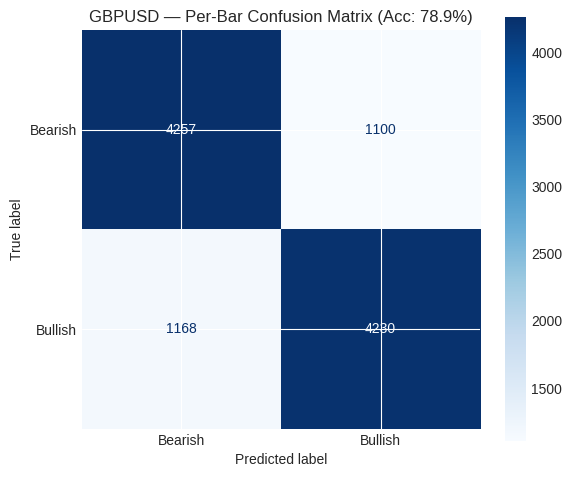

In [27]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Bearish', 'Bullish'])
disp.plot(ax=ax, cmap='Blues')
ax.set_title(f'{PAIR} — Per-Bar Confusion Matrix (Acc: {acc:.1%})')
plt.tight_layout()
plt.show()

### 8B. Per-DAY Accuracy (Majority Vote)

Since many 15M bars share the same target, we aggregate predictions per day to get the "final call" for each trading day.

In [28]:
# Build per-day summary
test_results = test[['date', 'datetime', 'target']].copy()
test_results['pred'] = y_pred
test_results['proba_bull'] = y_proba

# Method 1: Majority vote across all 15M predictions in the day
daily_vote = test_results.groupby('date').agg(
    actual=('target', 'first'),
    pred_mean=('pred', 'mean'),        # Fraction of bars predicted bullish
    proba_mean=('proba_bull', 'mean'),  # Avg P(bullish) across the day
    proba_last=('proba_bull', 'last'),  # Last bar's probability (most info)
    n_bars=('pred', 'count'),
).reset_index()

# Final daily prediction: avg proba > 0.5 → bullish
daily_vote['daily_pred'] = (daily_vote['proba_mean'] > 0.5).astype(int)
daily_vote['daily_pred_last'] = (daily_vote['proba_last'] > 0.5).astype(int)

day_acc_mean = accuracy_score(daily_vote['actual'], daily_vote['daily_pred'])
day_acc_last = accuracy_score(daily_vote['actual'], daily_vote['daily_pred_last'])

print('='*50)
print('PER-DAY ACCURACY')
print('='*50)
print(f'Days in test set:       {len(daily_vote)}')
print(f'Day Acc (avg proba):    {day_acc_mean:.4f}')
print(f'Day Acc (last bar):     {day_acc_last:.4f}')
print(f'\nDaily prediction breakdown (avg proba method):')
print(classification_report(
    daily_vote['actual'], daily_vote['daily_pred'],
    target_names=['Bearish Day', 'Bullish Day'], zero_division=0
))

PER-DAY ACCURACY
Days in test set:       270
Day Acc (avg proba):    0.8593
Day Acc (last bar):     0.8926

Daily prediction breakdown (avg proba method):
              precision    recall  f1-score   support

 Bearish Day       0.84      0.88      0.86       134
 Bullish Day       0.88      0.84      0.86       136

    accuracy                           0.86       270
   macro avg       0.86      0.86      0.86       270
weighted avg       0.86      0.86      0.86       270



### 8C. The "If/Then" Probability Trace

This is the key output: how `predict_proba` evolves through a single trading day as new 15M data arrives. You can see the model's confidence shift in real-time as FVGs get respected/disrespected and liquidity gets swept.

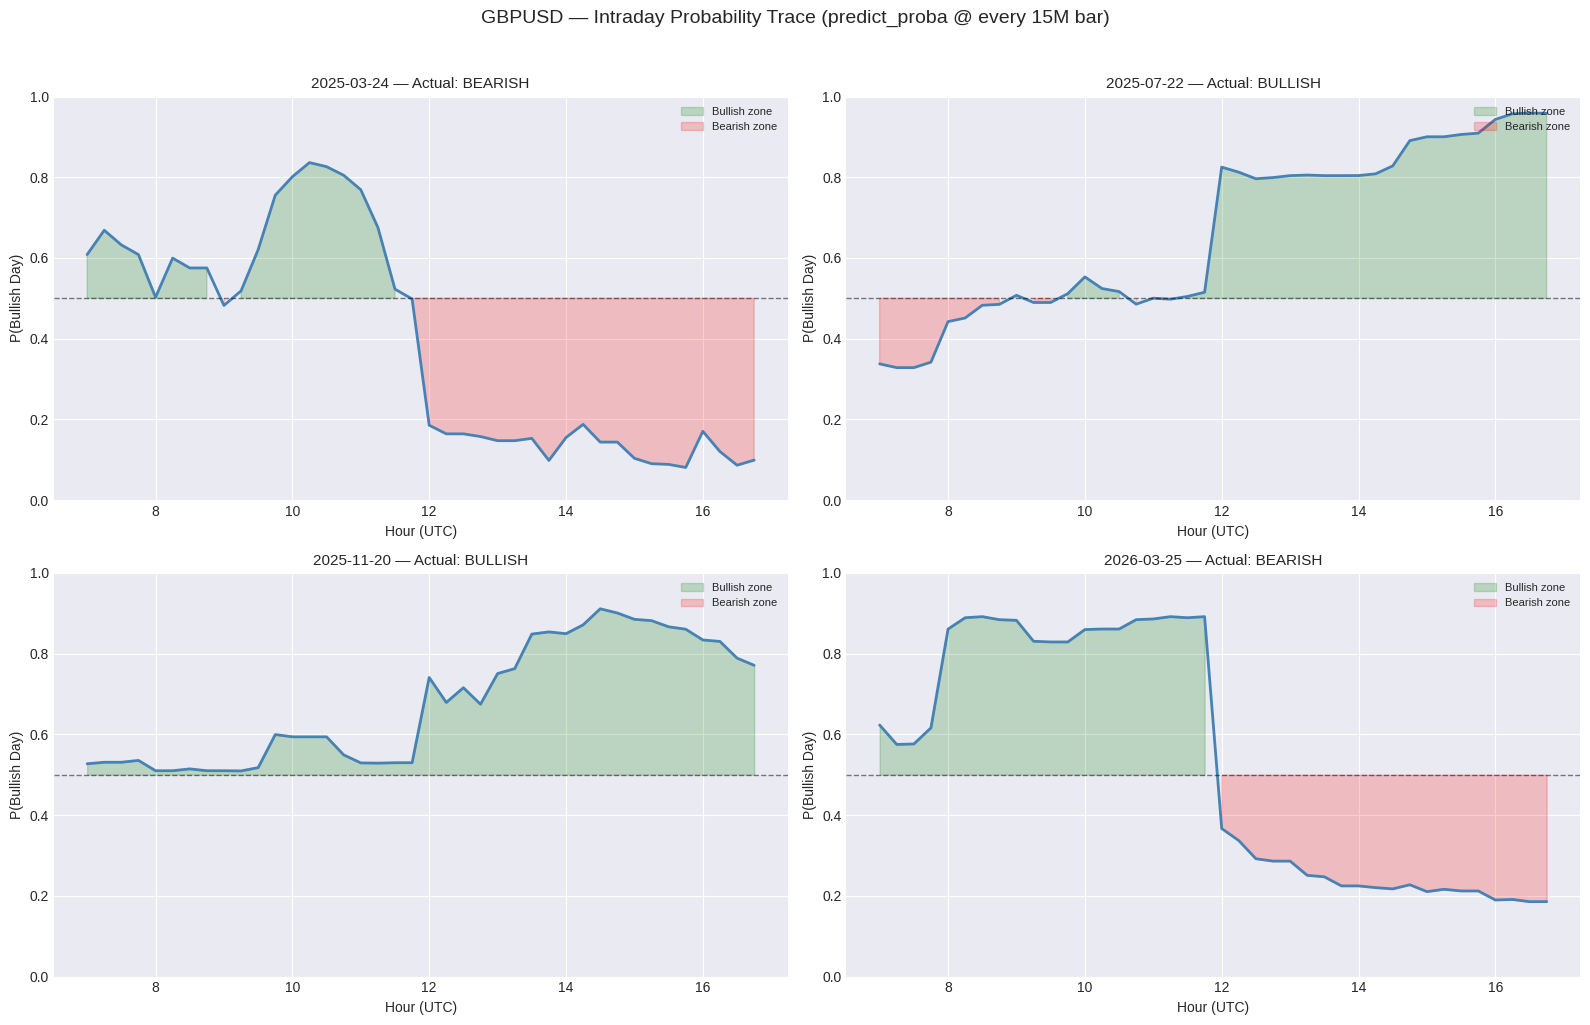

In [29]:
# Pick a few example days to visualise
unique_test_days = sorted(daily_vote['date'].unique())
# Select 4 sample days spread across the test period
sample_indices = np.linspace(5, len(unique_test_days) - 5, 4, dtype=int)
sample_days = [unique_test_days[i] for i in sample_indices]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, day in zip(axes.flat, sample_days):
    day_data = test_results[test_results['date'] == day].copy()
    if len(day_data) == 0:
        continue

    actual = day_data['target'].iloc[0]
    actual_str = 'BULLISH' if actual == 1 else 'BEARISH'
    hours = day_data['datetime'].dt.hour + day_data['datetime'].dt.minute / 60

    ax.plot(hours, day_data['proba_bull'], linewidth=2, color='steelblue')
    ax.axhline(0.5, color='black', linewidth=1, linestyle='--', alpha=0.5)
    ax.fill_between(hours, day_data['proba_bull'], 0.5,
                    where=day_data['proba_bull'] > 0.5,
                    alpha=0.2, color='green', label='Bullish zone')
    ax.fill_between(hours, day_data['proba_bull'], 0.5,
                    where=day_data['proba_bull'] <= 0.5,
                    alpha=0.2, color='red', label='Bearish zone')
    ax.set_ylim(0, 1)
    ax.set_xlabel('Hour (UTC)')
    ax.set_ylabel('P(Bullish Day)')
    ax.set_title(f'{day} — Actual: {actual_str}', fontsize=11)
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle(f'{PAIR} — Intraday Probability Trace (predict_proba @ every 15M bar)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 8D. Trading Performance (Daily)

In [30]:
def trading_performance(name, daily_df, pred_col='daily_pred'):
    """
    Simulate trading based on daily predictions.
    Position: +1 if predicted bullish, -1 if predicted bearish.
    Return: based on actual daily close direction.
    """
    positions = np.where(daily_df[pred_col] == 1, 1, -1).astype(float)
    # Actual daily return direction (simplified: +/- 1 unit per day)
    actual_dir = np.where(daily_df['actual'] == 1, 1, -1).astype(float)

    # Did we get the direction right?
    correct = (positions == actual_dir).astype(int)
    # Simple PnL: +1 for correct, -1 for wrong
    pnl = np.where(correct, 1, -1).astype(float)

    cum_pnl = np.cumsum(pnl)
    equity = 10000 + cum_pnl * 50  # $50 per unit

    win_rate = correct.mean() * 100
    total_pnl = cum_pnl[-1] * 50 if len(cum_pnl) > 0 else 0

    # Max drawdown
    running_max = np.maximum.accumulate(equity)
    dd = (equity / running_max - 1) * 100
    max_dd = dd.min()

    print(f'\n{"─"*50}')
    print(f'{name} — TRADING PERFORMANCE')
    print(f'{"─"*50}')
    print(f'Win Rate:       {win_rate:.1f}%')
    print(f'Total P&L:      ${total_pnl:+.0f} (at $50/unit)')
    print(f'Max Drawdown:   {max_dd:.1f}%')
    print(f'Trading Days:   {len(daily_df)}')

    return equity, dd


equity_mean, dd_mean = trading_performance('Avg Proba Method', daily_vote, 'daily_pred')
equity_last, dd_last = trading_performance('Last Bar Method', daily_vote, 'daily_pred_last')


──────────────────────────────────────────────────
Avg Proba Method — TRADING PERFORMANCE
──────────────────────────────────────────────────
Win Rate:       85.9%
Total P&L:      $+9700 (at $50/unit)
Max Drawdown:   -1.0%
Trading Days:   270

──────────────────────────────────────────────────
Last Bar Method — TRADING PERFORMANCE
──────────────────────────────────────────────────
Win Rate:       89.3%
Total P&L:      $+10600 (at $50/unit)
Max Drawdown:   -1.1%
Trading Days:   270


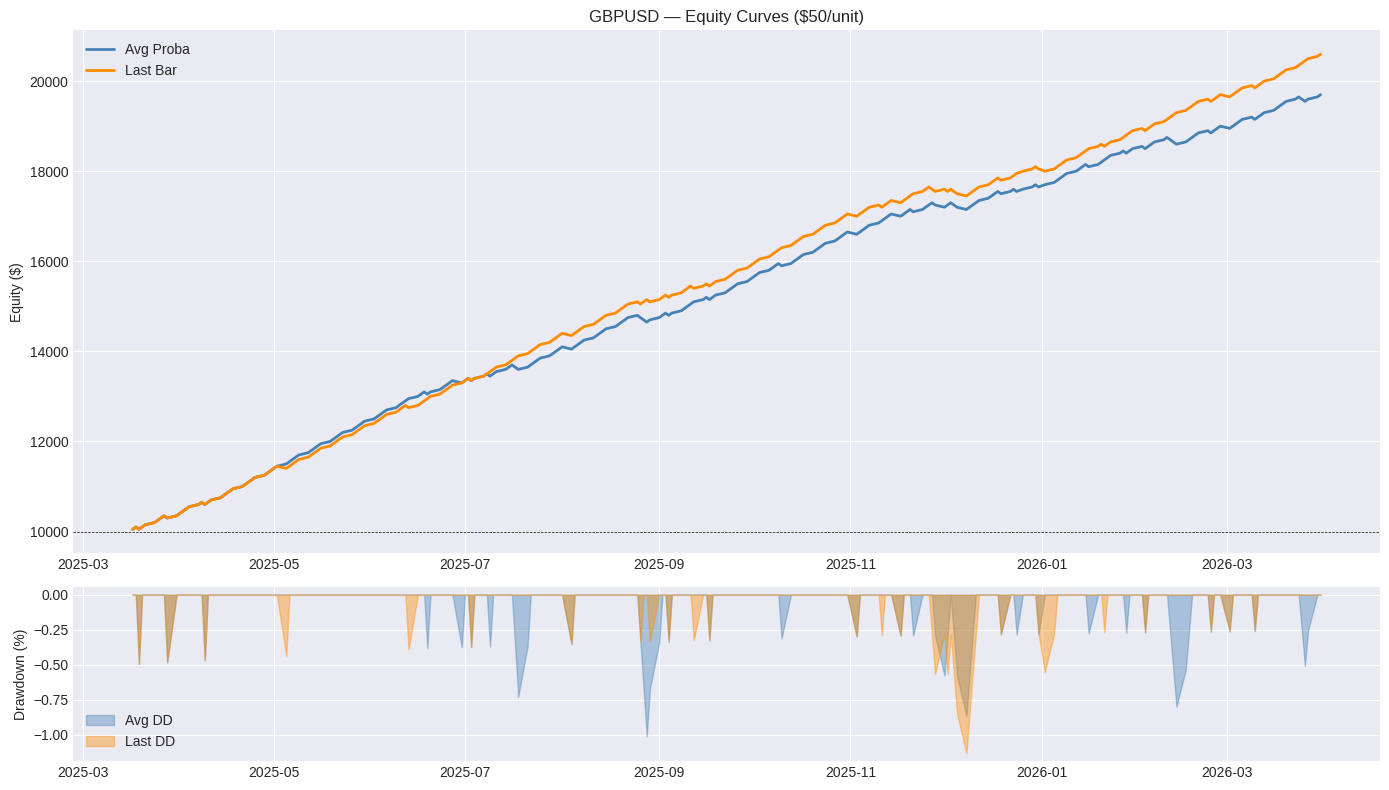

In [31]:
# ── Equity curves ──
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})

days = daily_vote['date'].values
axes[0].plot(days, equity_mean, label='Avg Proba', linewidth=2, color='steelblue')
axes[0].plot(days, equity_last, label='Last Bar', linewidth=2, color='darkorange')
axes[0].axhline(10000, color='black', linewidth=0.5, linestyle='--')
axes[0].set_ylabel('Equity ($)')
axes[0].set_title(f'{PAIR} — Equity Curves ($50/unit)')
axes[0].legend()

axes[1].fill_between(days, dd_mean, 0, alpha=0.4, color='steelblue', label='Avg DD')
axes[1].fill_between(days, dd_last, 0, alpha=0.4, color='darkorange', label='Last DD')
axes[1].set_ylabel('Drawdown (%)')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()

---
## 9. Feature Importance

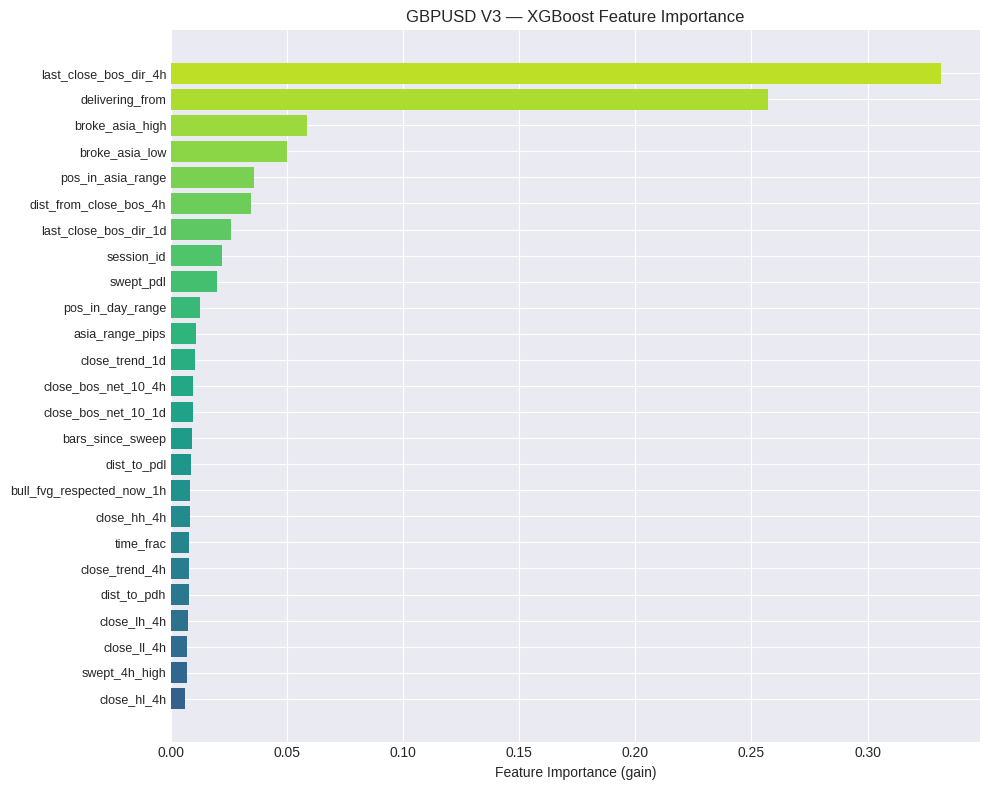

In [32]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1][:25]

fig, ax = plt.subplots(figsize=(10, 8))
top_features = [feature_cols[i] for i in indices]
top_importances = importances[indices]

colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_features)))
ax.barh(range(len(top_features)), top_importances[::-1], color=colors)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features[::-1], fontsize=9)
ax.set_xlabel('Feature Importance (gain)')
ax.set_title(f'{PAIR} V3 — XGBoost Feature Importance')
plt.tight_layout()
plt.show()

---
## 10. Hyperparameter Tuning

In [33]:
param_dist = {
    'n_estimators': [300, 500, 700, 1000],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.02, 0.03, 0.05],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8],
    'min_child_weight': [10, 15, 20, 30],
    'gamma': [0, 0.05, 0.1, 0.2, 0.3],
}

tscv = TimeSeriesSplit(n_splits=3)  # Fewer splits for large dataset

print('Tuning XGBoost (this may take several minutes)...')
search = RandomizedSearchCV(
    xgb.XGBClassifier(
        random_state=RANDOM_STATE, eval_metric='logloss',
        scale_pos_weight=scale_ratio, verbosity=0, n_jobs=-1,
    ),
    param_dist, n_iter=25, cv=tscv,
    scoring='roc_auc', random_state=RANDOM_STATE, verbose=1, n_jobs=-1
)
search.fit(X_train, y_train)

print(f'\nBest params: {search.best_params_}')
print(f'Best CV AUC: {search.best_score_:.4f}')

Tuning XGBoost (this may take several minutes)...
Fitting 3 folds for each of 25 candidates, totalling 75 fits

Best params: {'subsample': 0.6, 'n_estimators': 500, 'min_child_weight': 15, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.6}
Best CV AUC: 0.8594


In [34]:
# ── Evaluate tuned model ──
best_model = search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
y_proba_tuned = best_model.predict_proba(X_test)[:, 1]

acc_t = accuracy_score(y_test, y_pred_tuned)
auc_t = roc_auc_score(y_test, y_proba_tuned)
brier_t = brier_score_loss(y_test, y_proba_tuned)

print('='*50)
print('TUNED MODEL RESULTS')
print('='*50)
print(f'Accuracy:    {acc_t:.4f}  (baseline: {acc:.4f})')
print(f'ROC AUC:     {auc_t:.4f}  (baseline: {auc:.4f})')
print(f'Brier Score: {brier_t:.4f}  (baseline: {brier:.4f})')
print()
print(classification_report(
    y_test, y_pred_tuned,
    target_names=['Bearish Day', 'Bullish Day'], zero_division=0
))

# ── Per-day accuracy with tuned model ──
test_results['proba_tuned'] = y_proba_tuned
daily_vote_t = test_results.groupby('date').agg(
    actual=('target', 'first'),
    proba_mean=('proba_tuned', 'mean'),
).reset_index()
daily_vote_t['pred'] = (daily_vote_t['proba_mean'] > 0.5).astype(int)
day_acc_t = accuracy_score(daily_vote_t['actual'], daily_vote_t['pred'])
print(f'\nTuned Per-Day Accuracy: {day_acc_t:.4f}')

TUNED MODEL RESULTS
Accuracy:    0.7802  (baseline: 0.7891)
ROC AUC:     0.8819  (baseline: 0.8882)
Brier Score: 0.1416  (baseline: 0.1372)

              precision    recall  f1-score   support

 Bearish Day       0.77      0.80      0.78      5357
 Bullish Day       0.79      0.76      0.78      5398

    accuracy                           0.78     10755
   macro avg       0.78      0.78      0.78     10755
weighted avg       0.78      0.78      0.78     10755


Tuned Per-Day Accuracy: 0.8630


---
## 11. Mock Inference Example

This shows exactly how the model would be used in production: at each 15M candle close during London/NY, compute features and get `predict_proba()`.

In [35]:
# ── Mock: pick one day from test set and show the live probability trace ──
example_day = unique_test_days[len(unique_test_days) // 2]
day_slice = test_results[test_results['date'] == example_day].copy()

actual_outcome = 'BULLISH' if day_slice['target'].iloc[0] == 1 else 'BEARISH'

print(f'MOCK LIVE INFERENCE — {example_day}')
print(f'Actual daily outcome: {actual_outcome}')
print(f'{"─"*65}')
print(f'{"Time":>8s}  {"P(Bull)":>8s}  {"Bias":>10s}  {"Confidence":>10s}')
print(f'{"─"*65}')

for _, row in day_slice.iterrows():
    t = row['datetime'].strftime('%H:%M')
    p = row['proba_bull']
    bias = 'BULLISH' if p > 0.5 else 'BEARISH'
    conf = abs(p - 0.5) * 200  # 0-100% scale
    bar = '█' * int(conf / 5)
    print(f'{t:>8s}  {p:>8.1%}  {bias:>10s}  {conf:>7.1f}%  {bar}')

print(f'{"─"*65}')
final_p = day_slice['proba_bull'].iloc[-1]
final_call = 'BULLISH' if final_p > 0.5 else 'BEARISH'
correct = '✓ CORRECT' if final_call == actual_outcome else '✗ WRONG'
print(f'FINAL CALL: {final_call} ({final_p:.1%}) — {correct}')

MOCK LIVE INFERENCE — 2025-09-22
Actual daily outcome: BULLISH
─────────────────────────────────────────────────────────────────
    Time   P(Bull)        Bias  Confidence
─────────────────────────────────────────────────────────────────
   07:00     43.2%     BEARISH     13.6%  ██
   07:15     51.0%     BULLISH      2.1%  
   07:30     47.7%     BEARISH      4.6%  
   07:45     47.7%     BEARISH      4.6%  
   08:00     80.4%     BULLISH     60.8%  ████████████
   08:15     80.7%     BULLISH     61.3%  ████████████
   08:30     82.6%     BULLISH     65.1%  █████████████
   08:45     80.6%     BULLISH     61.2%  ████████████
   09:00     80.6%     BULLISH     61.2%  ████████████
   09:15     80.4%     BULLISH     60.7%  ████████████
   09:30     80.7%     BULLISH     61.3%  ████████████
   09:45     85.0%     BULLISH     70.0%  █████████████
   10:00     83.4%     BULLISH     66.9%  █████████████
   10:15     86.7%     BULLISH     73.4%  ██████████████
   10:30     82.6%     BULLISH   

---
## 12. Summary

### What V3 does differently

**Architecture:** Every 15M candle during London+NY is a prediction row. The model outputs `predict_proba()` at each interval, creating a dynamic probability trace that updates as new information arrives — FVGs get tested, liquidity gets swept, structure shifts.

**Features are pure SMC:**
1. **Close-only market structure** on 4H/Daily — filters out wick noise, reads structure like a line chart
2. **Delivery-from-liquidity state** — tracks whether BSL or SSL was most recently swept, encoding the ICT expectation of price delivering to the opposite side
3. **FVG respect/disrespect states** on 1H/15M — not just counting FVGs but tracking how price reacts to them on each specific bar, enabling conditional logic
4. **Session context** — Asia range, position within range, break direction, time fraction

**What was removed:** All MAs, RSI, MACD, Bollinger Bands, ATR, volatility regime, rolling vol, range percentile, Random Forest, regression target, interaction features that used MAs/ATR.

### How the "If/Then" works
XGBoost's decision trees naturally encode conditional chains. When a tree splits on `delivering_from == 1` (BSL swept) then splits on `bear_fvg_respected_now_1h == 1` then splits on `close_trend_4h == -1`, it's learned:

*"If BSL was swept AND a bearish 1H FVG was just respected AND the 4H close-trend is bearish → high probability of bearish daily close."*

The probability updates every 15 minutes as these conditions change.

### Next steps
- Add 1-minute data for finer entry timing
- Walk-forward retraining (monthly retrain)
- Confidence-based position sizing (only trade when P > 0.65)
- Multi-pair extension (EUR/USD, EUR/GBP)
- Order block detection as additional FVG-like feature
- SHAP values for per-prediction explainability